# Preprocessing the Wine Dataset

## Loading and Prepaing the Dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_wine = pd.read_csv("https://archive.ics.uci.edu/ml/"\
                      "machine-learning-databases/wine/wine.data",
                      header=None)

## Splitting the Dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y,
                                                    random_state=0)

## Standardizing the Dataset

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# Computing Class Mean Vector

In [ ]:
np.set_printoptions(precision=4)
mean_vecs = []
for label in range(1, 4):
  mean_vecs.append(np.mean(X_train_std[y_train==label], axis=0))
  print(f'MV {label}: {mean_vecs[label-1]}\n')

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 3: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]



# Computing S_W

In [ ]:
d = 13 # no. of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
  class_scatter = np.zeros((d, d))
  for row in X_train_std[y_train==label]:
    row, mv = row.reshape(d, 1), mv.reshape(d, 1)
    class_scatter += (row - mv).dot((row - mv).T)
  S_W += class_scatter

In [ ]:
print(f'Within-class matrix: {S_W.shape[0]} x {S_W.shape[1]}')

Within-class matrix: 13 x 13


## Scaled S_W

In [ ]:
d = 13 # no. of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
  class_scatter = np.cov(X_train_std[y_train==label].T)
  S_W += class_scatter

In [ ]:
print(f'Within-class matrix: {S_W.shape[0]} x {S_W.shape[1]}')

Within-class matrix: 13 x 13


# Computing S_B

In [ ]:
# Overall mean vector
mean_overall = np.mean(X_train_std, axis=0)
mean_overall = mean_overall.reshape(d, 1)

In [ ]:
d = 13 # no. of features
S_B = np.zeros((d, d))
for i, mean_vec in enumerate(mean_vecs):
  n = X_train_std[y_train==i+1, :].shape[0]
  mean_vec = mean_vec.reshape(d, 1) # Make column vector
  S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

In [ ]:
print(f'Between-class matrix: {S_B.shape[0]} x {S_B.shape[1]}')

Between-class matrix: 13 x 13


# Computing Eigenpairs using linalg.eig

In [ ]:
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

# Sorting Eigenvalues

In [ ]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]

In [ ]:
eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

In [ ]:
print('Eigenvalaues in descending order:\n')
for eigen_val in eigen_pairs:
  print(eigen_val[0])

Eigenvalaues in descending order:

349.61780890599397
172.7615221897938
3.277875948160424e-14
2.842170943040401e-14
2.6347620763320822e-14
2.6347620763320822e-14
1.7169492680170306e-14
1.7169492680170306e-14
1.674335053365992e-14
1.2740060380615543e-14
7.458378098449665e-15
4.737048557054326e-15
3.688843187314971e-15


# Discriminability

## Computing Discriminability

In [ ]:
tot = sum(eigen_vals.real)

In [ ]:
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]

In [ ]:
cum_discr = np.cumsum(discr)

## Plotting Discriminability

In [ ]:
import matplotlib.pyplot as plt

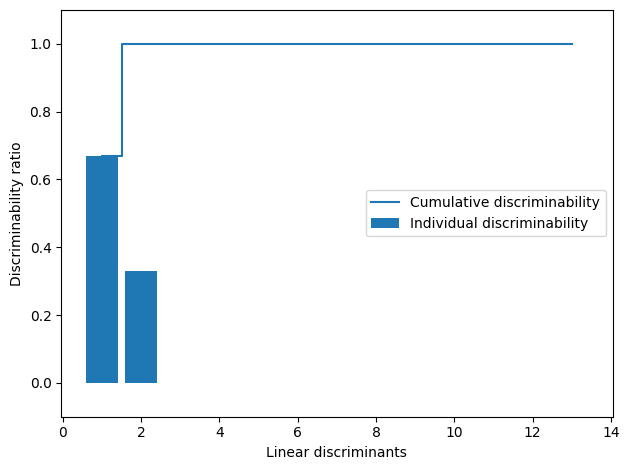

In [ ]:
plt.bar(range(1, 14), discr, align='center',
        label='Individual discriminability')
plt.step(range(1, 14), cum_discr, where='mid',
         label='Cumulative discriminability')
plt.ylabel('Discriminability ratio')
plt.xlabel('Linear discriminants')
plt.ylim([-0.1, 1.1])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Creating the Transformation Matrix (W)

In [ ]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis].real,
               eigen_pairs[1][1][:, np.newaxis].real))
print(w)

[[-0.1481 -0.4092]
 [ 0.0908 -0.1577]
 [-0.0168 -0.3537]
 [ 0.1484  0.3223]
 [-0.0163 -0.0817]
 [ 0.1913  0.0842]
 [-0.7338  0.2823]
 [-0.075  -0.0102]
 [ 0.0018  0.0907]
 [ 0.294  -0.2152]
 [-0.0328  0.2747]
 [-0.3547 -0.0124]
 [-0.3915 -0.5958]]


# Performing the transformation

In [ ]:
X_train_lda = X_train_std.dot(w)

# Visualizing LDA Data

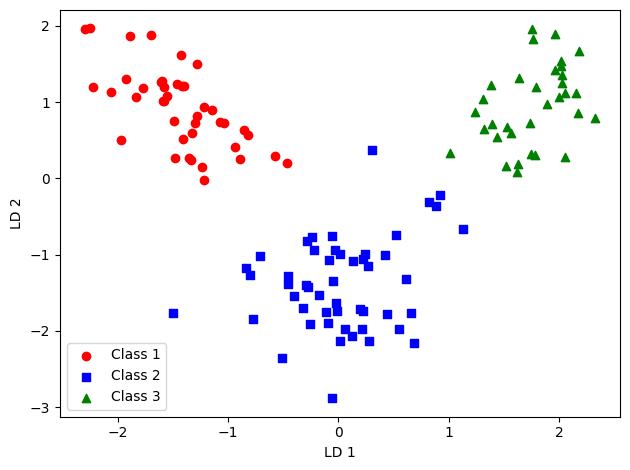

In [ ]:
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']
for l, c, m in zip(np.unique(y_train), colors, markers):
  plt.scatter(X_train_lda[y_train==l, 0],
              X_train_lda[y_train==l, 1] * (-1),
              c=c, marker=m, label=f'Class {l}')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()